In [ ]:
!pip install ipython-sql==0.5.0 prettytable==3.9.0
%load_ext sql
%config SqlMagic.style = 'PLAIN_COLUMNS'
%sql sqlite:///technocoding.db

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 30.9 MB/s eta 0:00:00
  Attempting uninstall: prettytable
    Found existing installation: prettytable 3.18.0
    Uninstalling prettytable-3.18.0:
      Successfully uninstalled prettytable-3.18.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import sqlite3

In [ ]:
response = requests.get("https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100")

In [ ]:
response.status_code

200

In [ ]:
data = response.json()

In [ ]:
df = pd.DataFrame(data['items'])
df

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76052,2867,197058,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34253,2382,164145,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,21954,11,89431,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15266,53,82496,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15612,24,74033,master,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,126573668,MDEwOlJlcG9zaXRvcnkxMjY1NzM2Njg=,Machine-learning-learning-notes,Vay-keen/Machine-learning-learning-notes,False,"{'login': 'Vay-keen', 'id': 9793783, 'node_id'...",https://github.com/Vay-keen/Machine-learning-l...,周志华《机器学习》又称西瓜书是一本较为全面的书籍，书中详细介绍了机器学习领域不同类型的算法(...,False,https://api.github.com/repos/Vay-keen/Machine-...,...,False,True,all,[],public,1879,28,7763,master,1.0
96,290234921,MDEwOlJlcG9zaXRvcnkyOTAyMzQ5MjE=,awesome-youtubers,JoseDeFreitas/awesome-youtubers,False,"{'login': 'JoseDeFreitas', 'id': 37962411, 'no...",https://github.com/JoseDeFreitas/awesome-youtu...,An awesome list of awesome YouTubers that teac...,False,https://api.github.com/repos/JoseDeFreitas/awe...,...,False,True,all,"[awesome, awesome-list, list, youtube, youtubers]",public,493,2,7685,main,1.0
97,123568881,MDEwOlJlcG9zaXRvcnkxMjM1Njg4ODE=,Learn_Machine_Learning_in_3_Months,llSourcell/Learn_Machine_Learning_in_3_Months,False,"{'login': 'llSourcell', 'id': 1279609, 'node_i...",https://github.com/llSourcell/Learn_Machine_Le...,"This is the code for ""Learn Machine Learning i...",False,https://api.github.com/repos/llSourcell/Learn_...,...,False,True,all,[],public,2311,19,7607,master,1.0
98,17371412,MDEwOlJlcG9zaXRvcnkxNzM3MTQxMg==,h2o-3,h2oai/h2o-3,False,"{'login': 'h2oai', 'id': 1402695, 'node_id': '...",https://github.com/h2oai/h2o-3,"H2O is an Open Source, Distributed, Fast & Sca...",False,https://api.github.com/repos/h2oai/h2o-3,...,False,True,all,"[automl, big-data, data-science, deep-learning...",public,2027,2880,7495,master,1.0


In [ ]:
df = df[["name", "owner" , "language" , "stargazers_count" , "forks_count" , "watchers_count" , "open_issues_count" , "created_at" , "updated_at" , "license"]]

In [ ]:
df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,"{'login': 'tensorflow', 'id': 15658638, 'node_...",C++,197058,76052,197058,2867,2015-11-07T01:19:20Z,2026-08-16T15:23:55Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,"{'login': 'huggingface', 'id': 25720743, 'node...",Python,164145,34253,164145,2382,2018-10-29T13:56:00Z,2026-08-16T15:29:18Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,"{'login': 'microsoft', 'id': 6154722, 'node_id...",Jupyter Notebook,89431,21954,89431,11,2021-03-03T01:34:05Z,2026-08-16T15:27:03Z,"{'key': 'mit', 'name': 'MIT License', 'spdx_id..."
3,funNLP,"{'login': 'fighting41love', 'id': 11475294, 'n...",Python,82496,15266,82496,53,2018-08-21T11:20:39Z,2026-08-16T15:15:47Z,None
4,awesome-machine-learning,"{'login': 'josephmisiti', 'id': 246302, 'node_...",Python,74033,15612,74033,24,2014-07-15T19:11:19Z,2026-08-16T15:26:51Z,"{'key': 'other', 'name': 'Other', 'spdx_id': '..."


In [ ]:
df['owner'] = df['owner'].apply(lambda x: x['login'] if isinstance(x, dict) and 'login' in x else None)
df.head()

/tmp/ipykernel_1380/940789107.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['owner'] = df['owner'].apply(lambda x: x['login'] if isinstance(x, dict) and 'login' in x else None)


,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,tensorflow,C++,197058,76052,197058,2867,2015-11-07T01:19:20Z,2026-08-16T15:23:55Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,huggingface,Python,164145,34253,164145,2382,2018-10-29T13:56:00Z,2026-08-16T15:29:18Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,microsoft,Jupyter Notebook,89431,21954,89431,11,2021-03-03T01:34:05Z,2026-08-16T15:27:03Z,"{'key': 'mit', 'name': 'MIT License', 'spdx_id..."
3,funNLP,fighting41love,Python,82496,15266,82496,53,2018-08-21T11:20:39Z,2026-08-16T15:15:47Z,None
4,awesome-machine-learning,josephmisiti,Python,74033,15612,74033,24,2014-07-15T19:11:19Z,2026-08-16T15:26:51Z,"{'key': 'other', 'name': 'Other', 'spdx_id': '..."


In [ ]:
df['license'] = df['license'].apply(lambda x: x['name'] if isinstance(x, dict) and 'name' in x else None)
df.head()

/tmp/ipykernel_1380/1604706228.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['license'] = df['license'].apply(lambda x: x['name'] if isinstance(x, dict) and 'name' in x else None)


,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,tensorflow,C++,197058,76052,197058,2867,2015-11-07T01:19:20Z,2026-08-16T15:23:55Z,Apache License 2.0
1,transformers,huggingface,Python,164145,34253,164145,2382,2018-10-29T13:56:00Z,2026-08-16T15:29:18Z,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89431,21954,89431,11,2021-03-03T01:34:05Z,2026-08-16T15:27:03Z,MIT License
3,funNLP,fighting41love,Python,82496,15266,82496,53,2018-08-21T11:20:39Z,2026-08-16T15:15:47Z,None
4,awesome-machine-learning,josephmisiti,Python,74033,15612,74033,24,2014-07-15T19:11:19Z,2026-08-16T15:26:51Z,Other


In [ ]:
df.isnull().sum()

,0
name,0
owner,0
language,23
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
license,22


In [ ]:
df['language'] = df['language'].fillna("unknown")

/tmp/ipykernel_1380/1903235388.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['language'] = df['language'].fillna("unknown")


In [ ]:
df['language']

,language
0,C++
1,Python
2,Jupyter Notebook
3,Python
4,Python
...,...
95,unknown
96,Markdown
97,unknown
98,Jupyter Notebook


In [ ]:
df['license'] = df['license'].fillna(df['license'].mode()[0])

/tmp/ipykernel_1380/2904474015.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['license'] = df['license'].fillna(df['license'].mode()[0])


In [ ]:
df['license']

,license
0,Apache License 2.0
1,Apache License 2.0
2,MIT License
3,MIT License
4,Other
...,...
95,MIT License
96,Creative Commons Zero v1.0 Universal
97,MIT License
98,Apache License 2.0


In [ ]:
df.isnull().sum()

,0
name,0
owner,0
language,0
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
license,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["created_date"] = df["created_at"]
df["updated_date"] = df['updated_at']
df["stars"] = df['stargazers_count']
df["forks"] = df['forks_count']
df["watchers"] = df['watchers_count']
df["open_issues"] = df['open_issues_count']
df = df.drop(columns=["stargazers_count" , "forks_count" , "watchers_count" , "open_issues_count" , "created_at" , "updated_at"])

/tmp/ipykernel_1380/133001280.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["created_date"] = df["created_at"]
/tmp/ipykernel_1380/133001280.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["updated_date"] = df['updated_at']
/tmp/ipykernel_1380/133001280.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

In [ ]:
df.head()

,name,owner,language,license,created_date,updated_date,stars,forks,watchers,open_issues
0,tensorflow,tensorflow,C++,Apache License 2.0,2015-11-07T01:19:20Z,2026-08-16T15:23:55Z,197058,76052,197058,2867
1,transformers,huggingface,Python,Apache License 2.0,2018-10-29T13:56:00Z,2026-08-16T15:29:18Z,164145,34253,164145,2382
2,ML-For-Beginners,microsoft,Jupyter Notebook,MIT License,2021-03-03T01:34:05Z,2026-08-16T15:27:03Z,89431,21954,89431,11
3,funNLP,fighting41love,Python,MIT License,2018-08-21T11:20:39Z,2026-08-16T15:15:47Z,82496,15266,82496,53
4,awesome-machine-learning,josephmisiti,Python,Other,2014-07-15T19:11:19Z,2026-08-16T15:26:51Z,74033,15612,74033,24


In [ ]:
df['created_date'] = pd.to_datetime(df['created_date'] , format="mixed")
df['updated_date'] = pd.to_datetime(df['updated_date'] , format="mixed")
df['updated_date']

,updated_date
0,2026-08-16 15:23:55+00:00
1,2026-08-16 15:29:18+00:00
2,2026-08-16 15:27:03+00:00
3,2026-08-16 15:15:47+00:00
4,2026-08-16 15:26:51+00:00
...,...
95,2026-08-14 17:10:02+00:00
96,2026-08-16 13:04:40+00:00
97,2026-08-16 03:59:02+00:00
98,2026-08-16 15:26:27+00:00


In [ ]:
df.to_csv("github_projects.csv" , index=False)

In [ ]:
df = pd.read_csv("/content/github_projects.csv")

In [ ]:
df.to_sql("Reposatories" , "sqlite:///technocoding.db" , index = False , if_exists="replace")

100

In [ ]:
%%sql
select * from Reposatories

 * sqlite:///technocoding.db
Done.


name,owner,language,license,created_date,updated_date,stars,forks,watchers,open_issues
tensorflow,tensorflow,C++,Apache License 2.0,2015-11-07 01:19:20+00:00,2026-08-16 15:23:55+00:00,197058,76052,197058,2867
transformers,huggingface,Python,Apache License 2.0,2018-10-29 13:56:00+00:00,2026-08-16 15:29:18+00:00,164145,34253,164145,2382
ML-For-Beginners,microsoft,Jupyter Notebook,MIT License,2021-03-03 01:34:05+00:00,2026-08-16 15:27:03+00:00,89431,21954,89431,11
funNLP,fighting41love,Python,MIT License,2018-08-21 11:20:39+00:00,2026-08-16 15:15:47+00:00,82496,15266,82496,53
awesome-machine-learning,josephmisiti,Python,Other,2014-07-15 19:11:19+00:00,2026-08-16 15:26:51+00:00,74033,15612,74033,24
scikit-learn,scikit-learn,Python,"BSD 3-Clause ""New"" or ""Revised"" License",2010-08-17 09:43:38+00:00,2026-08-16 12:48:36+00:00,66960,27290,66960,2128
gradio,gradio-app,Python,Apache License 2.0,2018-12-19 08:24:04+00:00,2026-08-16 15:26:51+00:00,43370,3574,43370,184
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,unknown,MIT License,2021-01-02 12:08:37+00:00,2026-08-16 15:25:33+00:00,36300,7435,36300,67
C-Plus-Plus,TheAlgorithms,C++,MIT License,2016-07-16 10:19:45+00:00,2026-08-16 12:46:04+00:00,34582,7852,34582,32
netron,lutzroeder,JavaScript,MIT License,2010-12-26 12:53:43+00:00,2026-08-16 15:15:41+00:00,33360,3172,33360,16


In [ ]:
%%sql
select * from Reposatories
where stars > 10000

 * sqlite:///technocoding.db
Done.


name,owner,language,license,created_date,updated_date,stars,forks,watchers,open_issues
tensorflow,tensorflow,C++,Apache License 2.0,2015-11-07 01:19:20+00:00,2026-08-16 15:23:55+00:00,197058,76052,197058,2867
transformers,huggingface,Python,Apache License 2.0,2018-10-29 13:56:00+00:00,2026-08-16 15:29:18+00:00,164145,34253,164145,2382
ML-For-Beginners,microsoft,Jupyter Notebook,MIT License,2021-03-03 01:34:05+00:00,2026-08-16 15:27:03+00:00,89431,21954,89431,11
funNLP,fighting41love,Python,MIT License,2018-08-21 11:20:39+00:00,2026-08-16 15:15:47+00:00,82496,15266,82496,53
awesome-machine-learning,josephmisiti,Python,Other,2014-07-15 19:11:19+00:00,2026-08-16 15:26:51+00:00,74033,15612,74033,24
scikit-learn,scikit-learn,Python,"BSD 3-Clause ""New"" or ""Revised"" License",2010-08-17 09:43:38+00:00,2026-08-16 12:48:36+00:00,66960,27290,66960,2128
gradio,gradio-app,Python,Apache License 2.0,2018-12-19 08:24:04+00:00,2026-08-16 15:26:51+00:00,43370,3574,43370,184
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,unknown,MIT License,2021-01-02 12:08:37+00:00,2026-08-16 15:25:33+00:00,36300,7435,36300,67
C-Plus-Plus,TheAlgorithms,C++,MIT License,2016-07-16 10:19:45+00:00,2026-08-16 12:46:04+00:00,34582,7852,34582,32
netron,lutzroeder,JavaScript,MIT License,2010-12-26 12:53:43+00:00,2026-08-16 15:15:41+00:00,33360,3172,33360,16


In [ ]:
%%sql
select * from Reposatories
where name like "%Machine%"

 * sqlite:///technocoding.db
Done.


name,owner,language,license,created_date,updated_date,stars,forks,watchers,open_issues
awesome-machine-learning,josephmisiti,Python,Other,2014-07-15 19:11:19+00:00,2026-08-16 15:26:51+00:00,74033,15612,74033,24
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,unknown,MIT License,2021-01-02 12:08:37+00:00,2026-08-16 15:25:33+00:00,36300,7435,36300,67
machine-learning-for-software-engineers,ZuzooVn,unknown,Creative Commons Attribution Share Alike 4.0 International,2016-10-09 21:20:25+00:00,2026-08-15 19:57:02+00:00,28860,6148,28860,32
homemade-machine-learning,trekhleb,Jupyter Notebook,MIT License,2018-11-01 04:34:19+00:00,2026-08-16 13:19:22+00:00,24758,4195,24758,31
awesome-production-machine-learning,EthicalML,unknown,MIT License,2018-08-15 14:28:41+00:00,2026-08-16 08:26:39+00:00,20847,2590,20847,31
machine-learning-for-trading,stefan-jansen,Jupyter Notebook,MIT License,2018-05-09 12:33:08+00:00,2026-08-16 15:15:20+00:00,20475,5521,20475,5
stanford-cs-229-machine-learning,afshinea,unknown,MIT License,2018-08-04 23:01:00+00:00,2026-08-16 13:48:06+00:00,20108,4248,20108,20
Machine-Learning-Tutorials,ujjwalkarn,unknown,Creative Commons Zero v1.0 Universal,2015-09-12 14:51:38+00:00,2026-08-16 07:08:58+00:00,18105,3970,18105,47
machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,MIT License,2020-04-17 04:29:23+00:00,2026-08-16 14:51:06+00:00,13920,3093,13920,3
machine-learning-interview,khangich,unknown,MIT License,2020-08-11 06:26:32+00:00,2026-08-16 09:45:17+00:00,12784,2043,12784,9


In [ ]:
%%sql
select * from Reposatories
where stars > 10000 and name like "%Machine%"

 * sqlite:///technocoding.db
Done.


name,owner,language,license,created_date,updated_date,stars,forks,watchers,open_issues
awesome-machine-learning,josephmisiti,Python,Other,2014-07-15 19:11:19+00:00,2026-08-16 15:26:51+00:00,74033,15612,74033,24
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,unknown,MIT License,2021-01-02 12:08:37+00:00,2026-08-16 15:25:33+00:00,36300,7435,36300,67
machine-learning-for-software-engineers,ZuzooVn,unknown,Creative Commons Attribution Share Alike 4.0 International,2016-10-09 21:20:25+00:00,2026-08-15 19:57:02+00:00,28860,6148,28860,32
homemade-machine-learning,trekhleb,Jupyter Notebook,MIT License,2018-11-01 04:34:19+00:00,2026-08-16 13:19:22+00:00,24758,4195,24758,31
awesome-production-machine-learning,EthicalML,unknown,MIT License,2018-08-15 14:28:41+00:00,2026-08-16 08:26:39+00:00,20847,2590,20847,31
machine-learning-for-trading,stefan-jansen,Jupyter Notebook,MIT License,2018-05-09 12:33:08+00:00,2026-08-16 15:15:20+00:00,20475,5521,20475,5
stanford-cs-229-machine-learning,afshinea,unknown,MIT License,2018-08-04 23:01:00+00:00,2026-08-16 13:48:06+00:00,20108,4248,20108,20
Machine-Learning-Tutorials,ujjwalkarn,unknown,Creative Commons Zero v1.0 Universal,2015-09-12 14:51:38+00:00,2026-08-16 07:08:58+00:00,18105,3970,18105,47
machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,MIT License,2020-04-17 04:29:23+00:00,2026-08-16 14:51:06+00:00,13920,3093,13920,3
machine-learning-interview,khangich,unknown,MIT License,2020-08-11 06:26:32+00:00,2026-08-16 09:45:17+00:00,12784,2043,12784,9


In [ ]:
%%sql
select * from Reposatories
where watchers > 26000 and language = "Python"

 * sqlite:///technocoding.db
Done.


name,owner,language,license,created_date,updated_date,stars,forks,watchers,open_issues
transformers,huggingface,Python,Apache License 2.0,2018-10-29 13:56:00+00:00,2026-08-16 15:29:18+00:00,164145,34253,164145,2382
funNLP,fighting41love,Python,MIT License,2018-08-21 11:20:39+00:00,2026-08-16 15:15:47+00:00,82496,15266,82496,53
awesome-machine-learning,josephmisiti,Python,Other,2014-07-15 19:11:19+00:00,2026-08-16 15:26:51+00:00,74033,15612,74033,24
scikit-learn,scikit-learn,Python,"BSD 3-Clause ""New"" or ""Revised"" License",2010-08-17 09:43:38+00:00,2026-08-16 12:48:36+00:00,66960,27290,66960,2128
gradio,gradio-app,Python,Apache License 2.0,2018-12-19 08:24:04+00:00,2026-08-16 15:26:51+00:00,43370,3574,43370,184
ML-From-Scratch,eriklindernoren,Python,MIT License,2017-02-05 12:11:23+00:00,2026-08-16 12:46:05+00:00,32476,5429,32476,78
linkedin-skill-assessments-quizzes,Ebazhanov,Python,GNU Affero General Public License v3.0,2019-07-13 19:52:56+00:00,2026-08-16 15:17:37+00:00,28812,12915,28812,21
cs249r_book,harvard-edge,Python,Other,2023-09-06 19:31:06+00:00,2026-08-16 15:28:20+00:00,27935,3525,27935,32


In [ ]:
%%sql
select * from Reposatories
where license = "Other" or forks < 15000

 * sqlite:///technocoding.db
Done.


name,owner,language,license,created_date,updated_date,stars,forks,watchers,open_issues
awesome-machine-learning,josephmisiti,Python,Other,2014-07-15 19:11:19+00:00,2026-08-16 15:26:51+00:00,74033,15612,74033,24
gradio,gradio-app,Python,Apache License 2.0,2018-12-19 08:24:04+00:00,2026-08-16 15:26:51+00:00,43370,3574,43370,184
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,unknown,MIT License,2021-01-02 12:08:37+00:00,2026-08-16 15:25:33+00:00,36300,7435,36300,67
C-Plus-Plus,TheAlgorithms,C++,MIT License,2016-07-16 10:19:45+00:00,2026-08-16 12:46:04+00:00,34582,7852,34582,32
netron,lutzroeder,JavaScript,MIT License,2010-12-26 12:53:43+00:00,2026-08-16 15:15:41+00:00,33360,3172,33360,16
ML-From-Scratch,eriklindernoren,Python,MIT License,2017-02-05 12:11:23+00:00,2026-08-16 12:46:05+00:00,32476,5429,32476,78
applied-ml,eugeneyan,unknown,MIT License,2020-07-04 18:57:47+00:00,2026-08-16 13:02:43+00:00,30045,3990,30045,8
machine-learning-for-software-engineers,ZuzooVn,unknown,Creative Commons Attribution Share Alike 4.0 International,2016-10-09 21:20:25+00:00,2026-08-15 19:57:02+00:00,28860,6148,28860,32
linkedin-skill-assessments-quizzes,Ebazhanov,Python,GNU Affero General Public License v3.0,2019-07-13 19:52:56+00:00,2026-08-16 15:17:37+00:00,28812,12915,28812,21
cs249r_book,harvard-edge,Python,Other,2023-09-06 19:31:06+00:00,2026-08-16 15:28:20+00:00,27935,3525,27935,32


In [ ]:
%%sql
select * from Reposatories
where license = "Apache License 2.0" or open_issues > 349

 * sqlite:///technocoding.db
Done.


name,owner,language,license,created_date,updated_date,stars,forks,watchers,open_issues
tensorflow,tensorflow,C++,Apache License 2.0,2015-11-07 01:19:20+00:00,2026-08-16 15:23:55+00:00,197058,76052,197058,2867
transformers,huggingface,Python,Apache License 2.0,2018-10-29 13:56:00+00:00,2026-08-16 15:29:18+00:00,164145,34253,164145,2382
scikit-learn,scikit-learn,Python,"BSD 3-Clause ""New"" or ""Revised"" License",2010-08-17 09:43:38+00:00,2026-08-16 12:48:36+00:00,66960,27290,66960,2128
gradio,gradio-app,Python,Apache License 2.0,2018-12-19 08:24:04+00:00,2026-08-16 15:26:51+00:00,43370,3574,43370,184
shap,shap,Jupyter Notebook,MIT License,2016-11-22 19:17:08+00:00,2026-08-16 11:03:39+00:00,25686,3741,25686,1013
Paddle,PaddlePaddle,C++,Apache License 2.0,2016-08-15 06:59:08+00:00,2026-08-16 13:34:30+00:00,24052,6014,24052,1522
onnx,onnx,Python,Apache License 2.0,2017-09-07 04:53:45+00:00,2026-08-16 13:02:42+00:00,21317,3999,21317,278
rasa,RasaHQ,Python,Apache License 2.0,2016-10-14 12:27:49+00:00,2026-08-16 11:07:02+00:00,21296,4919,21296,153
LightGBM,lightgbm-org,C++,MIT License,2016-08-05 05:45:50+00:00,2026-08-16 15:25:34+00:00,18687,4050,18687,512
brpc,apache,C++,Apache License 2.0,2017-09-04 09:28:47+00:00,2026-08-16 10:01:27+00:00,17581,4130,17581,461


In [ ]:
%%sql
select * from Reposatories
where not language = "C++"

 * sqlite:///technocoding.db
Done.


name,owner,language,license,created_date,updated_date,stars,forks,watchers,open_issues
transformers,huggingface,Python,Apache License 2.0,2018-10-29 13:56:00+00:00,2026-08-16 15:29:18+00:00,164145,34253,164145,2382
ML-For-Beginners,microsoft,Jupyter Notebook,MIT License,2021-03-03 01:34:05+00:00,2026-08-16 15:27:03+00:00,89431,21954,89431,11
funNLP,fighting41love,Python,MIT License,2018-08-21 11:20:39+00:00,2026-08-16 15:15:47+00:00,82496,15266,82496,53
awesome-machine-learning,josephmisiti,Python,Other,2014-07-15 19:11:19+00:00,2026-08-16 15:26:51+00:00,74033,15612,74033,24
scikit-learn,scikit-learn,Python,"BSD 3-Clause ""New"" or ""Revised"" License",2010-08-17 09:43:38+00:00,2026-08-16 12:48:36+00:00,66960,27290,66960,2128
gradio,gradio-app,Python,Apache License 2.0,2018-12-19 08:24:04+00:00,2026-08-16 15:26:51+00:00,43370,3574,43370,184
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,unknown,MIT License,2021-01-02 12:08:37+00:00,2026-08-16 15:25:33+00:00,36300,7435,36300,67
netron,lutzroeder,JavaScript,MIT License,2010-12-26 12:53:43+00:00,2026-08-16 15:15:41+00:00,33360,3172,33360,16
ML-From-Scratch,eriklindernoren,Python,MIT License,2017-02-05 12:11:23+00:00,2026-08-16 12:46:05+00:00,32476,5429,32476,78
applied-ml,eugeneyan,unknown,MIT License,2020-07-04 18:57:47+00:00,2026-08-16 13:02:43+00:00,30045,3990,30045,8


In [ ]:
%%sql
select * from Reposatories
where not license = "Apache License 2.0"

 * sqlite:///technocoding.db
Done.


name,owner,language,license,created_date,updated_date,stars,forks,watchers,open_issues
ML-For-Beginners,microsoft,Jupyter Notebook,MIT License,2021-03-03 01:34:05+00:00,2026-08-16 15:27:03+00:00,89431,21954,89431,11
funNLP,fighting41love,Python,MIT License,2018-08-21 11:20:39+00:00,2026-08-16 15:15:47+00:00,82496,15266,82496,53
awesome-machine-learning,josephmisiti,Python,Other,2014-07-15 19:11:19+00:00,2026-08-16 15:26:51+00:00,74033,15612,74033,24
scikit-learn,scikit-learn,Python,"BSD 3-Clause ""New"" or ""Revised"" License",2010-08-17 09:43:38+00:00,2026-08-16 12:48:36+00:00,66960,27290,66960,2128
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,unknown,MIT License,2021-01-02 12:08:37+00:00,2026-08-16 15:25:33+00:00,36300,7435,36300,67
C-Plus-Plus,TheAlgorithms,C++,MIT License,2016-07-16 10:19:45+00:00,2026-08-16 12:46:04+00:00,34582,7852,34582,32
netron,lutzroeder,JavaScript,MIT License,2010-12-26 12:53:43+00:00,2026-08-16 15:15:41+00:00,33360,3172,33360,16
ML-From-Scratch,eriklindernoren,Python,MIT License,2017-02-05 12:11:23+00:00,2026-08-16 12:46:05+00:00,32476,5429,32476,78
applied-ml,eugeneyan,unknown,MIT License,2020-07-04 18:57:47+00:00,2026-08-16 13:02:43+00:00,30045,3990,30045,8
machine-learning-for-software-engineers,ZuzooVn,unknown,Creative Commons Attribution Share Alike 4.0 International,2016-10-09 21:20:25+00:00,2026-08-15 19:57:02+00:00,28860,6148,28860,32


In [ ]:
%%sql
select * from Reposatories
order by stars DESC
limit 10

 * sqlite:///technocoding.db
Done.


name,owner,language,license,created_date,updated_date,stars,forks,watchers,open_issues
tensorflow,tensorflow,C++,Apache License 2.0,2015-11-07 01:19:20+00:00,2026-08-16 15:23:55+00:00,197058,76052,197058,2867
transformers,huggingface,Python,Apache License 2.0,2018-10-29 13:56:00+00:00,2026-08-16 15:29:18+00:00,164145,34253,164145,2382
ML-For-Beginners,microsoft,Jupyter Notebook,MIT License,2021-03-03 01:34:05+00:00,2026-08-16 15:27:03+00:00,89431,21954,89431,11
funNLP,fighting41love,Python,MIT License,2018-08-21 11:20:39+00:00,2026-08-16 15:15:47+00:00,82496,15266,82496,53
awesome-machine-learning,josephmisiti,Python,Other,2014-07-15 19:11:19+00:00,2026-08-16 15:26:51+00:00,74033,15612,74033,24
scikit-learn,scikit-learn,Python,"BSD 3-Clause ""New"" or ""Revised"" License",2010-08-17 09:43:38+00:00,2026-08-16 12:48:36+00:00,66960,27290,66960,2128
gradio,gradio-app,Python,Apache License 2.0,2018-12-19 08:24:04+00:00,2026-08-16 15:26:51+00:00,43370,3574,43370,184
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,unknown,MIT License,2021-01-02 12:08:37+00:00,2026-08-16 15:25:33+00:00,36300,7435,36300,67
C-Plus-Plus,TheAlgorithms,C++,MIT License,2016-07-16 10:19:45+00:00,2026-08-16 12:46:04+00:00,34582,7852,34582,32
netron,lutzroeder,JavaScript,MIT License,2010-12-26 12:53:43+00:00,2026-08-16 15:15:41+00:00,33360,3172,33360,16


In [ ]:
%%sql
select count(*) as number_of_reposatories from Reposatories

 * sqlite:///technocoding.db
Done.


number_of_reposatories
100


In [ ]:
%%sql
select avg(stars) from Reposatories

 * sqlite:///technocoding.db
Done.


avg(stars)
20792.93


In [ ]:
%%sql
select language , count(*) as numberofreposatories from Reposatories
group by language
having count(*) > 5

 * sqlite:///technocoding.db
Done.


language,numberofreposatories
C++,12
Jupyter Notebook,19
Python,30
unknown,23


Text(0, 0.5, 'Stars')

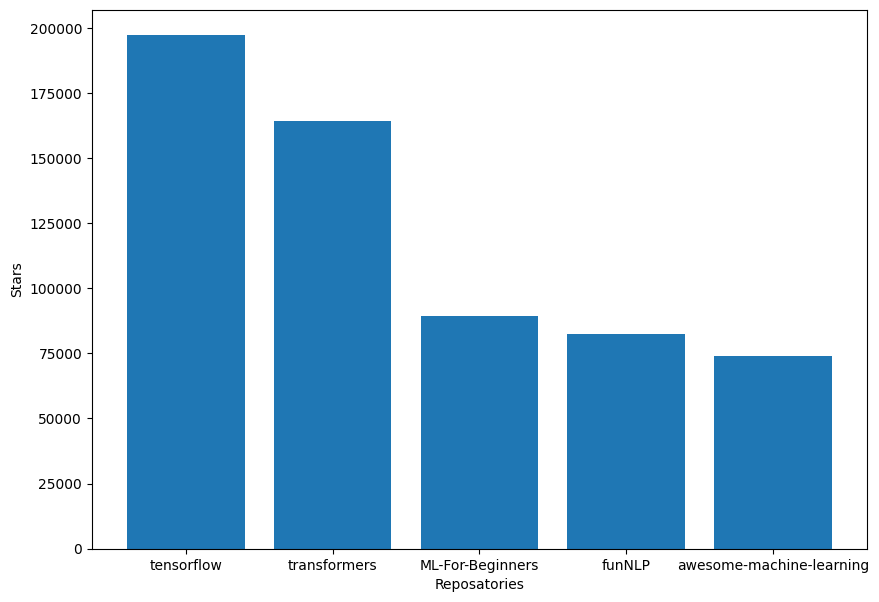

In [ ]:
plt.figure(figsize=(10,7))
plt.bar(df['name'][:5] , df['stars'][:5])
plt.xlabel("Reposatories")
plt.ylabel("Stars")

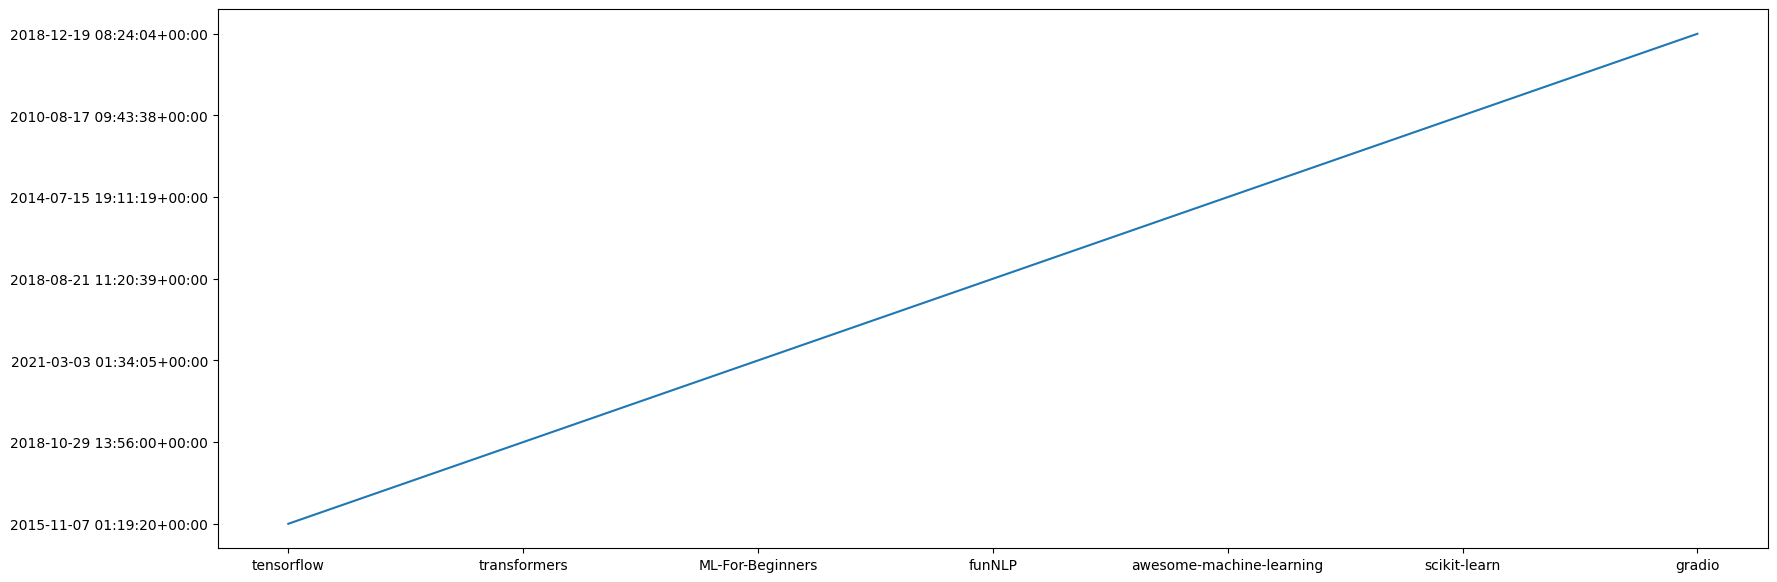

In [ ]:
plt.figure(figsize=(20,7))
plt.plot(df['name'][:7] , df['created_date'][:7])

there are a total of 100 reposatories in this dataset

the most popular reposatory is tensorflow  

the most used programming language is python which was used in 30 reposatories

projects were created accros diffrent periods showing the growing use of github in projects